In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/custom.css
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/results/rf_metrics.csv
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/results/rf_confusion_matrix.png
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/results/rf_classification_report.csv
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/models/random_forest.pkl
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/__results___files/__results___11_0.png
/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/__results___files/__results___16_0.png
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/3-feature-selecti

In [2]:
import joblib

rf = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/models/random_forest.pkl"
)

print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [3]:
import joblib

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

feature_names = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/3-feature-selection/outputs/features/feature_names.pkl"
)

print(X_train.shape)
print(len(feature_names))

(5055991, 77)
77


In [4]:
import pandas as pd
import numpy as np

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

print(X_train_df.shape)

(5055991, 77)


In [5]:
CORR_SAMPLE_SIZE = 100_000

rng = np.random.RandomState(42)

corr_idx = rng.choice(
    len(X_train_df),
    size=min(CORR_SAMPLE_SIZE, len(X_train_df)),
    replace=False
)

X_corr = X_train_df.iloc[corr_idx]

print(X_corr.shape)

(100000, 77)


In [6]:
corr_matrix = X_corr.corr(method="pearson")

corr_matrix.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Protocol,1.000000,-0.240308,0.036938,-0.017851,0.035390,-0.011295,-0.329833,0.666820,-0.158121,-0.359337,...,0.037641,-0.666758,-0.053728,-0.053305,-0.063908,-0.038948,-0.187811,-0.015426,-0.185826,-0.187231
Flow Duration,-0.240308,1.000000,0.057566,0.063681,0.058771,0.050454,-0.042796,-0.087851,-0.156113,-0.106511,...,0.056063,-0.026015,0.141915,0.153449,0.194172,0.100847,0.720654,0.197944,0.729176,0.704589
Total Fwd Packets,0.036938,0.057566,1.000000,0.011776,0.981263,0.011906,-0.012858,0.016936,-0.009245,-0.014273,...,0.999839,-0.027888,0.000095,0.000225,0.000327,0.000034,-0.006046,-0.000825,-0.006052,-0.006005
Total Backward Packets,-0.017851,0.063681,0.011776,1.000000,0.007863,0.998506,0.024787,-0.013711,-0.004828,0.001367,...,-0.000424,0.010363,0.062170,0.018066,0.062957,0.066263,0.027377,0.020614,0.028393,0.025446
Fwd Packets Length Total,0.035390,0.058771,0.981263,0.007863,1.000000,0.002063,-0.003485,0.016422,0.014577,-0.007102,...,0.981347,-0.025667,0.001889,0.004773,0.005391,0.000257,-0.006614,0.000283,-0.006510,-0.006722


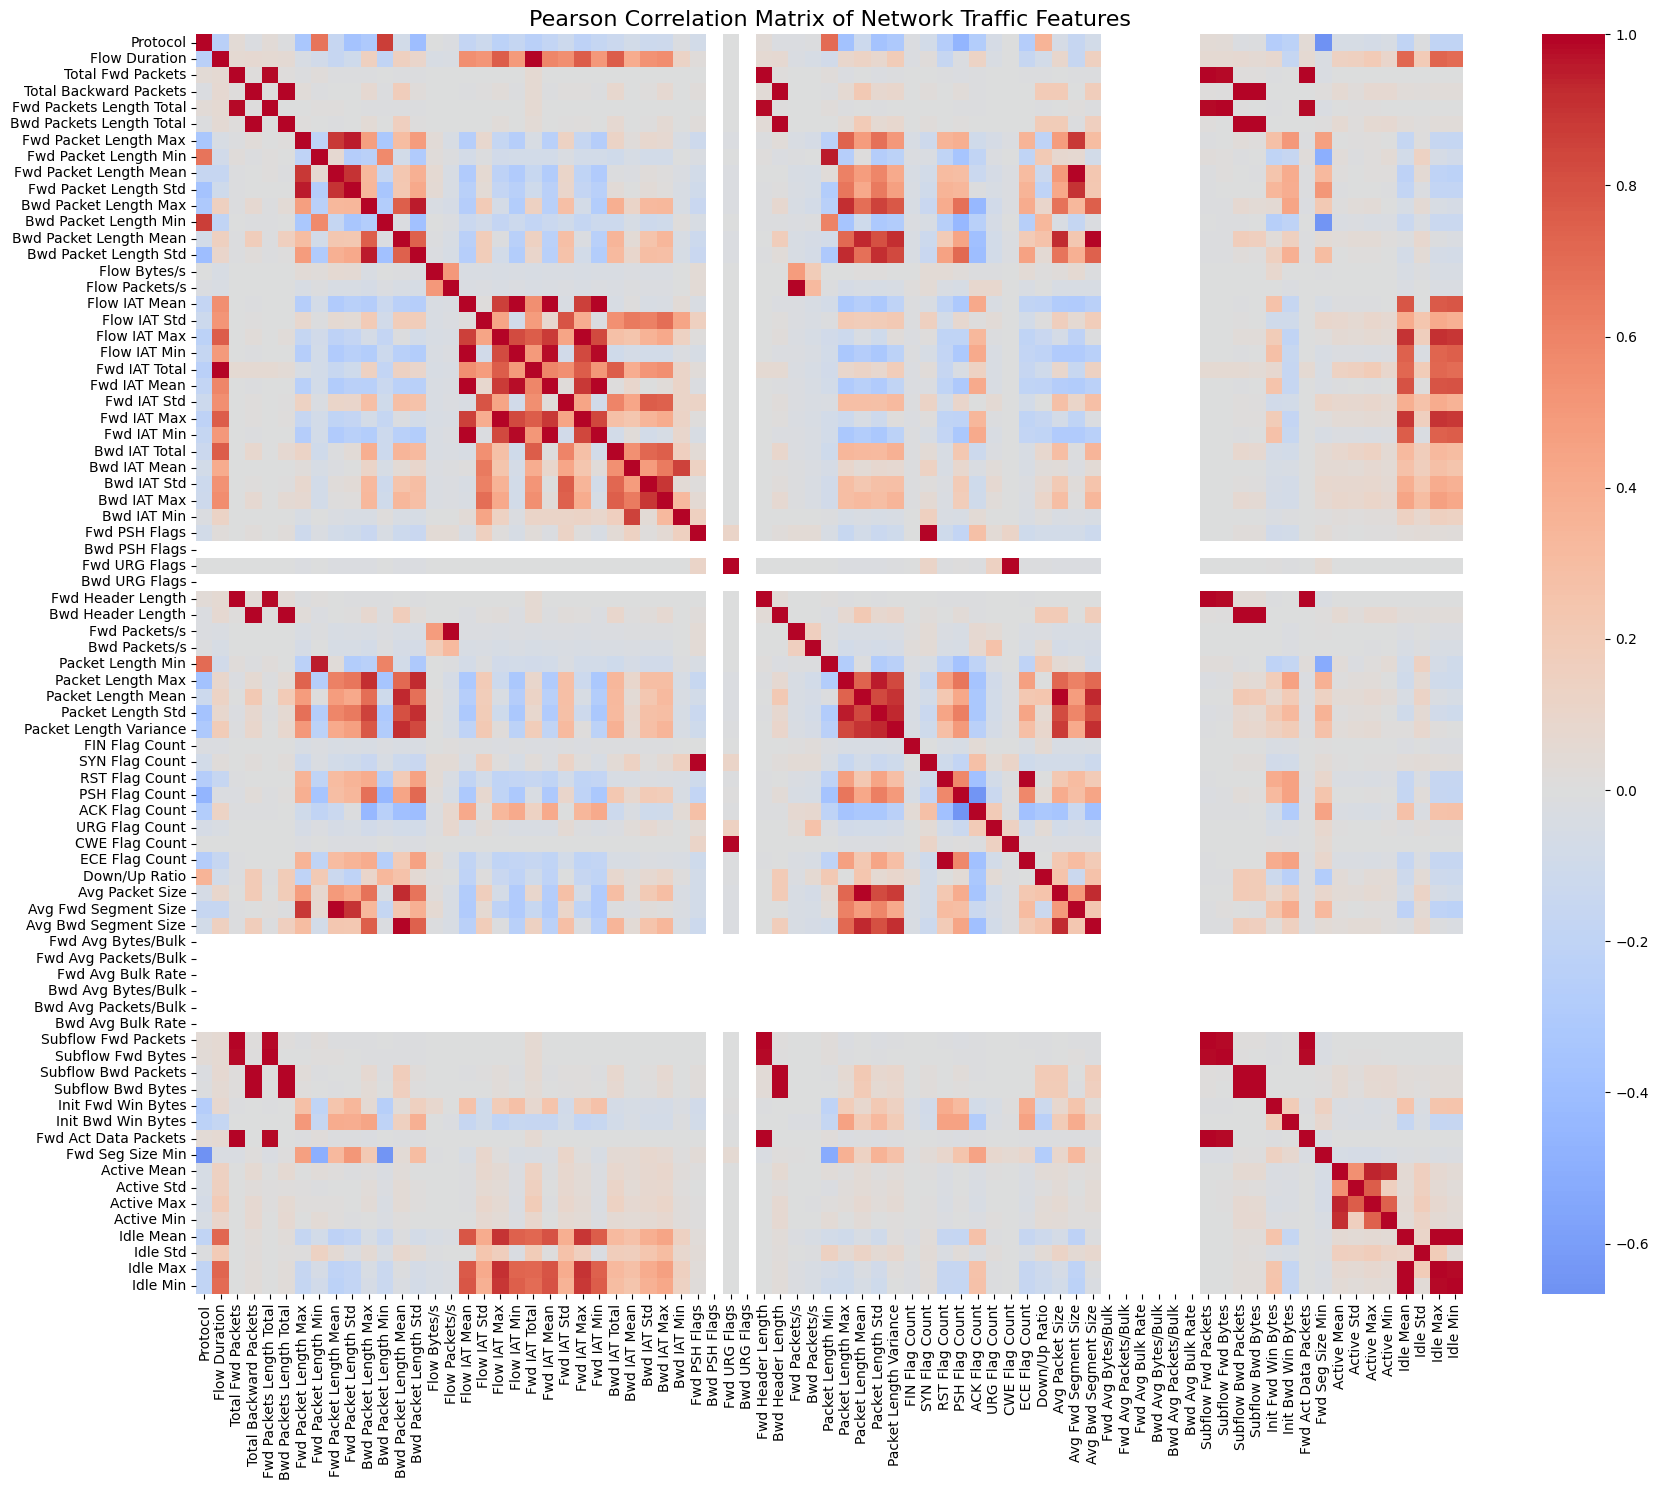

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=False
)

plt.title(
    "Pearson Correlation Matrix of Network Traffic Features",
    fontsize=16
)

plt.tight_layout()



plt.show()

In [8]:
threshold = 0.90

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"].abs() >= threshold
]

high_corr_pairs = high_corr_pairs.sort_values(
    "Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

high_corr_pairs.head(30)

,Feature_1,Feature_2,Correlation
185,Total Fwd Packets,Subflow Fwd Packets,1.000000
315,Fwd Packets Length Total,Subflow Fwd Bytes,1.000000
252,Total Backward Packets,Subflow Bwd Packets,1.000000
789,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
558,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
1616,Fwd PSH Flags,SYN Flag Count,1.000000
2025,RST Flag Count,ECE Flag Count,1.000000
1658,Fwd URG Flags,CWE Flag Count,1.000000
380,Bwd Packets Length Total,Subflow Bwd Bytes,1.000000
2231,Subflow Fwd Packets,Fwd Act Data Packets,0.999839


In [9]:
print(
    "Highly correlated pairs:",
    len(high_corr_pairs)
)

Highly correlated pairs: 61


In [10]:
# Count how many high-correlation relationships each feature has
feature_corr_count = pd.concat([
    high_corr_pairs["Feature_1"],
    high_corr_pairs["Feature_2"]
]).value_counts()

feature_corr_count = feature_corr_count.rename(
    "High_Correlation_Count"
).to_frame()

feature_corr_count.head(30)

,High_Correlation_Count
Total Fwd Packets,5
Fwd Packets Length Total,5
Fwd Header Length,5
Subflow Fwd Packets,5
Fwd Act Data Packets,5
Subflow Fwd Bytes,5
Bwd Header Length,4
Bwd Packets Length Total,4
Subflow Bwd Packets,4
Avg Bwd Segment Size,4


In [11]:
print("Features involved in high correlations:",
      len(feature_corr_count))

print("Total features:",
      len(feature_names))

Features involved in high correlations: 48
Total features: 77


In [12]:
# Show features involved in the most high-correlation relationships

feature_corr_count = pd.concat([
    high_corr_pairs["Feature_1"],
    high_corr_pairs["Feature_2"]
]).value_counts()

feature_corr_count = (
    feature_corr_count
    .rename("High_Correlation_Count")
    .reset_index()
)

feature_corr_count.columns = [
    "Feature",
    "High_Correlation_Count"
]

feature_corr_count.head(30)

,Feature,High_Correlation_Count
0,Total Fwd Packets,5
1,Fwd Packets Length Total,5
2,Fwd Header Length,5
3,Subflow Fwd Packets,5
4,Fwd Act Data Packets,5
5,Subflow Fwd Bytes,5
6,Bwd Header Length,4
7,Bwd Packets Length Total,4
8,Subflow Bwd Packets,4
9,Avg Bwd Segment Size,4


In [13]:
top_redundant = feature_corr_count.head(13)["Feature"].tolist()

top_pairs = high_corr_pairs[
    high_corr_pairs["Feature_1"].isin(top_redundant) |
    high_corr_pairs["Feature_2"].isin(top_redundant)
].sort_values(
    "Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

print(top_pairs.to_string(index=False))

               Feature_1                Feature_2  Correlation
       Total Fwd Packets      Subflow Fwd Packets     1.000000
Fwd Packets Length Total        Subflow Fwd Bytes     1.000000
  Total Backward Packets      Subflow Bwd Packets     1.000000
  Bwd Packet Length Mean     Avg Bwd Segment Size     1.000000
Bwd Packets Length Total        Subflow Bwd Bytes     1.000000
     Subflow Fwd Packets     Fwd Act Data Packets     0.999839
       Total Fwd Packets     Fwd Act Data Packets     0.999839
  Total Backward Packets        Bwd Header Length     0.999699
       Bwd Header Length      Subflow Bwd Packets     0.999699
       Fwd Header Length      Subflow Fwd Packets     0.999400
       Total Fwd Packets        Fwd Header Length     0.999400
Bwd Packets Length Total        Bwd Header Length     0.998683
       Bwd Header Length        Subflow Bwd Bytes     0.998683
       Fwd Header Length     Fwd Act Data Packets     0.998650
  Total Backward Packets Bwd Packets Length Total     0

In [14]:
import networkx as nx

# Create graph from highly correlated pairs
G = nx.Graph()

for _, row in high_corr_pairs.iterrows():
    G.add_edge(
        row["Feature_1"],
        row["Feature_2"]
    )

# Find connected components
correlation_groups = list(
    nx.connected_components(G)
)

# Sort largest groups first
correlation_groups = sorted(
    correlation_groups,
    key=len,
    reverse=True
)

for i, group in enumerate(correlation_groups, 1):
    print(f"\nGroup {i} ({len(group)} features):")
    print(sorted(group))


Group 1 (9 features):
['Avg Bwd Segment Size', 'Avg Packet Size', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance']

Group 2 (6 features):
['Fwd Act Data Packets', 'Fwd Header Length', 'Fwd Packets Length Total', 'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'Total Fwd Packets']

Group 3 (5 features):
['Bwd Header Length', 'Bwd Packets Length Total', 'Subflow Bwd Bytes', 'Subflow Bwd Packets', 'Total Backward Packets']

Group 4 (5 features):
['Flow IAT Max', 'Fwd IAT Max', 'Idle Max', 'Idle Mean', 'Idle Min']

Group 5 (4 features):
['Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Min']

Group 6 (3 features):
['Active Max', 'Active Mean', 'Active Min']

Group 7 (2 features):
['Avg Fwd Segment Size', 'Fwd Packet Length Mean']

Group 8 (2 features):
['Fwd PSH Flags', 'SYN Flag Count']

Group 9 (2 features):
['ECE Flag Count', 'RST Flag Count']

Group 10 (2 features)

In [15]:
corr_threshold_99 = 0.99

high_corr_99 = high_corr_pairs[
    high_corr_pairs["Correlation"].abs() >= corr_threshold_99
].copy()

high_corr_99 = high_corr_99.sort_values(
    "Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

print("Pairs with |r| >= 0.99:", len(high_corr_99))

print(
    high_corr_99.to_string(index=False)
)

Pairs with |r| >= 0.99: 31
               Feature_1                Feature_2  Correlation
       Total Fwd Packets      Subflow Fwd Packets     1.000000
Fwd Packets Length Total        Subflow Fwd Bytes     1.000000
  Total Backward Packets      Subflow Bwd Packets     1.000000
  Bwd Packet Length Mean     Avg Bwd Segment Size     1.000000
  Fwd Packet Length Mean     Avg Fwd Segment Size     1.000000
           Fwd PSH Flags           SYN Flag Count     1.000000
          RST Flag Count           ECE Flag Count     1.000000
           Fwd URG Flags           CWE Flag Count     1.000000
Bwd Packets Length Total        Subflow Bwd Bytes     1.000000
     Subflow Fwd Packets     Fwd Act Data Packets     0.999839
       Total Fwd Packets     Fwd Act Data Packets     0.999839
  Total Backward Packets        Bwd Header Length     0.999699
       Bwd Header Length      Subflow Bwd Packets     0.999699
       Fwd Header Length      Subflow Fwd Packets     0.999400
       Total Fwd Packets    

In [16]:
import networkx as nx

G99 = nx.Graph()

for _, row in high_corr_99.iterrows():

    G99.add_edge(
        row["Feature_1"],
        row["Feature_2"]
    )

groups_99 = sorted(
    nx.connected_components(G99),
    key=len,
    reverse=True
)

print("Number of strong redundancy groups:", len(groups_99))

for i, group in enumerate(groups_99, 1):

    print(f"\nGroup {i} ({len(group)} features):")
    print(sorted(group))

Number of strong redundancy groups: 13

Group 1 (5 features):
['Bwd Header Length', 'Bwd Packets Length Total', 'Subflow Bwd Bytes', 'Subflow Bwd Packets', 'Total Backward Packets']

Group 2 (4 features):
['Fwd Act Data Packets', 'Fwd Header Length', 'Subflow Fwd Packets', 'Total Fwd Packets']

Group 3 (4 features):
['Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Min']

Group 4 (3 features):
['Idle Max', 'Idle Mean', 'Idle Min']

Group 5 (2 features):
['Fwd Packets Length Total', 'Subflow Fwd Bytes']

Group 6 (2 features):
['Avg Bwd Segment Size', 'Bwd Packet Length Mean']

Group 7 (2 features):
['Avg Fwd Segment Size', 'Fwd Packet Length Mean']

Group 8 (2 features):
['Fwd PSH Flags', 'SYN Flag Count']

Group 9 (2 features):
['ECE Flag Count', 'RST Flag Count']

Group 10 (2 features):
['CWE Flag Count', 'Fwd URG Flags']

Group 11 (2 features):
['Flow Duration', 'Fwd IAT Total']

Group 12 (2 features):
['Avg Packet Size', 'Packet Length Mean']

Group 13 (2 features):
['Flow 

In [17]:
print(hasattr(rf, "feature_importances_"))

True


In [18]:
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "RF_Importance",
    ascending=False
).reset_index(drop=True)

rf_importance.head(20)

,Feature,RF_Importance
0,Init Fwd Win Bytes,0.056600
1,Fwd Packets Length Total,0.043038
2,Subflow Fwd Bytes,0.041164
3,Fwd Seg Size Min,0.039508
4,Fwd Header Length,0.032311
5,Flow IAT Mean,0.029256
6,Fwd IAT Mean,0.026852
7,Fwd Packet Length Max,0.026549
8,Avg Fwd Segment Size,0.026161
9,Flow IAT Max,0.025783


In [19]:
selected_from_groups = []
group_selection_results = []

for i, group in enumerate(groups_99, 1):

    group_df = rf_importance[
        rf_importance["Feature"].isin(group)
    ].copy()

    group_df = group_df.sort_values(
        "RF_Importance",
        ascending=False
    )

    best_feature = group_df.iloc[0]["Feature"]

    selected_from_groups.append(best_feature)

    group_selection_results.append({
        "Group": i,
        "Group_Size": len(group),
        "Selected_Feature": best_feature,
        "RF_Importance": group_df.iloc[0]["RF_Importance"],
        "All_Group_Features": ", ".join(sorted(group))
    })

group_selection_df = pd.DataFrame(
    group_selection_results
)

group_selection_df

,Group,Group_Size,Selected_Feature,RF_Importance,All_Group_Features
0,1,5,Bwd Header Length,0.017408,"Bwd Header Length, Bwd Packets Length Total, S..."
1,2,4,Fwd Header Length,0.032311,"Fwd Act Data Packets, Fwd Header Length, Subfl..."
2,3,4,Flow IAT Mean,0.029256,"Flow IAT Mean, Flow IAT Min, Fwd IAT Mean, Fwd..."
3,4,3,Idle Max,0.009681,"Idle Max, Idle Mean, Idle Min"
4,5,2,Fwd Packets Length Total,0.043038,"Fwd Packets Length Total, Subflow Fwd Bytes"
5,6,2,Avg Bwd Segment Size,0.025296,"Avg Bwd Segment Size, Bwd Packet Length Mean"
6,7,2,Avg Fwd Segment Size,0.026161,"Avg Fwd Segment Size, Fwd Packet Length Mean"
7,8,2,Fwd PSH Flags,0.000177,"Fwd PSH Flags, SYN Flag Count"
8,9,2,RST Flag Count,0.019882,"ECE Flag Count, RST Flag Count"
9,10,2,Fwd URG Flags,0.000038,"CWE Flag Count, Fwd URG Flags"


In [20]:
selected_from_groups = []
group_selection_results = []

for i, group in enumerate(groups_99, 1):

    group_df = rf_importance[
        rf_importance["Feature"].isin(group)
    ].copy()

    group_df = group_df.sort_values(
        "RF_Importance",
        ascending=False
    )

    best_feature = group_df.iloc[0]["Feature"]

    selected_from_groups.append(best_feature)

    group_selection_results.append({
        "Group": i,
        "Group_Size": len(group),
        "Selected_Feature": best_feature,
        "RF_Importance": group_df.iloc[0]["RF_Importance"],
        "All_Group_Features": ", ".join(sorted(group))
    })

group_selection_df = pd.DataFrame(group_selection_results)

group_selection_df

,Group,Group_Size,Selected_Feature,RF_Importance,All_Group_Features
0,1,5,Bwd Header Length,0.017408,"Bwd Header Length, Bwd Packets Length Total, S..."
1,2,4,Fwd Header Length,0.032311,"Fwd Act Data Packets, Fwd Header Length, Subfl..."
2,3,4,Flow IAT Mean,0.029256,"Flow IAT Mean, Flow IAT Min, Fwd IAT Mean, Fwd..."
3,4,3,Idle Max,0.009681,"Idle Max, Idle Mean, Idle Min"
4,5,2,Fwd Packets Length Total,0.043038,"Fwd Packets Length Total, Subflow Fwd Bytes"
5,6,2,Avg Bwd Segment Size,0.025296,"Avg Bwd Segment Size, Bwd Packet Length Mean"
6,7,2,Avg Fwd Segment Size,0.026161,"Avg Fwd Segment Size, Fwd Packet Length Mean"
7,8,2,Fwd PSH Flags,0.000177,"Fwd PSH Flags, SYN Flag Count"
8,9,2,RST Flag Count,0.019882,"ECE Flag Count, RST Flag Count"
9,10,2,Fwd URG Flags,0.000038,"CWE Flag Count, Fwd URG Flags"


In [21]:
group_features = set()

for group in groups_99:
    group_features.update(group)

non_correlated_features = [
    f for f in feature_names
    if f not in group_features
]

correlation_reduced_features = (
    non_correlated_features +
    selected_from_groups
)

print("Original features:", len(feature_names))
print("Reduced features:", len(correlation_reduced_features))

Original features: 77
Reduced features: 56


In [22]:
X_train_corr = X_train_df[
    correlation_reduced_features
].copy()

X_test_corr = X_test_df[
    correlation_reduced_features
].copy()

print("X_train:", X_train_corr.shape)
print("X_test :", X_test_corr.shape)

X_train: (5055991, 56)
X_test : (1263998, 56)


In [23]:
import os
import joblib

os.makedirs(
    "outputs/feature_selection/correlation",
    exist_ok=True
)

joblib.dump(
    correlation_reduced_features,
    "outputs/feature_selection/correlation/correlation_reduced_features.pkl"
)

group_selection_df.to_csv(
    "outputs/feature_selection/correlation/group_representatives.csv",
    index=False
)

In [24]:
from lightgbm import LGBMClassifier

lgb_56 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

In [25]:
import time

start = time.time()

lgb_56.fit(
    X_train_corr,
    y_train
)

elapsed = (time.time() - start) / 60

print(f"Training time: {elapsed:.2f} minutes")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.737476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9312
[LightGBM] [Info] Number of data points in the train set: 5055991, number of used features: 48
[LightGBM] [Info] Start training from score -0.235451
[LightGBM] [Info] Start training from score -3.777951
[LightGBM] [Info] Start training from score -9.344775
[LightGBM] [Info] Start training from score -10.226598
[LightGBM] [Info] Start training from score -3.458865
[LightGBM] [Info] Start training from score -8.203351
[LightGBM] [Info] Start training from score -2.396470
[LightGBM] [Info] Start training from score -5.028041
[LightGBM] [Info] Start training from score -3.773369
[LightGBM] [Info] Start training from score -11.651895
[LightGBM] [Info] Start

In [26]:
y_pred_lgb_56 = lgb_56.predict(
    X_test_corr
)

y_prob_lgb_56 = lgb_56.predict_proba(
    X_test_corr
)

print("Prediction shape:", y_pred_lgb_56.shape)
print("Probability shape:", y_prob_lgb_56.shape)

Prediction shape: (1263998,)
Probability shape: (1263998, 15)


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

accuracy_56 = accuracy_score(
    y_test,
    y_pred_lgb_56
)

precision_56 = precision_score(
    y_test,
    y_pred_lgb_56,
    average="weighted"
)

recall_56 = recall_score(
    y_test,
    y_pred_lgb_56,
    average="weighted"
)

f1_56 = f1_score(
    y_test,
    y_pred_lgb_56,
    average="weighted"
)
mcc_56 =matthews_corrcoef(
    y_test,
    y_pred_lgb_56
)

auc_56 = roc_auc_score(
    y_test,
    y_prob_lgb_56,
    multi_class="ovr",
    average="weighted"
)


print(f"Accuracy : {accuracy_56:.4f}")
print(f"Precision: {precision_56:.4f}")
print(f"Recall   : {recall_56:.4f}")
print(f"F1       : {f1_56:.4f}")
print(f"mcc      : {mcc_56:.4f}")
print(f"AUC      : {auc_56:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy : 0.9089
Precision: 0.9225
Recall   : 0.9089
F1       : 0.9150
mcc      : 0.7525
AUC      : 0.8976


In [28]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

print(classification_report(
    y_test,
    y_pred_lgb_56,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.96      0.96      0.96    998829
                     Bot       0.98      0.87      0.92     28907
        Brute Force -Web       0.00      0.00      0.00       111
        Brute Force -XSS       0.00      0.00      0.00        45
        DDOS attack-HOIC       0.94      0.88      0.91     39772
    DDoS attack-LOIC-UDP       0.00      0.00      0.00       346
  DDoS attacks-LOIC-HTTP       0.97      0.93      0.95    115073
   DoS attacks-GoldenEye       0.90      0.56      0.69      8281
        DoS attacks-Hulk       0.13      0.07      0.09     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.00      0.00      0.00      1982
          FTP-BruteForce       0.00      0.00      0.00        10
            Infiltration       0.04      0.08      0.06     22764
           SQL Injection       0.00      0.00      0.00        17
         

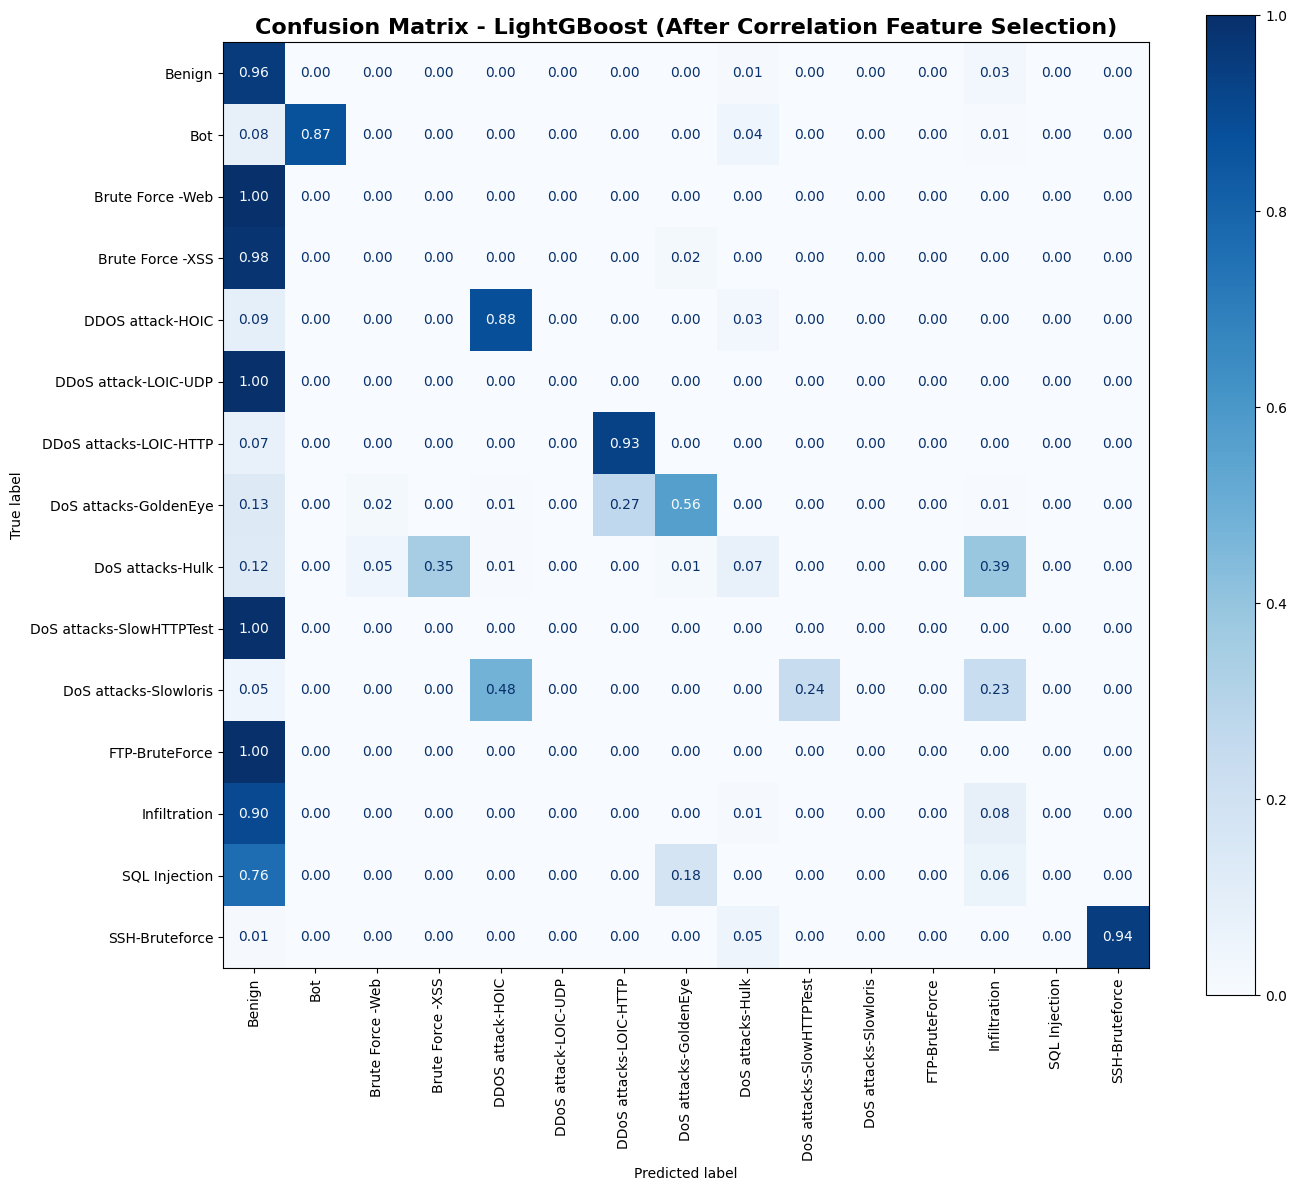

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lgb_56,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - LightGBoost (After Correlation Feature Selection)",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()

plt.show()

In [30]:
import os

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [31]:
import joblib

joblib.dump(
    lgb_56,
    "outputs/models/lgb_56.pkl"
)

print("lgb_56 model saved!")

lgb_56 model saved!


In [32]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["LightGBoost"],
    "Accuracy": [accuracy_56],
    "Precision": [precision_56],
    "Recall": [recall_56],
    "F1": [f1_56],
    "MCC": [mcc_56],
    "AUC": [auc_56]
})

metrics_df.to_csv(
    "outputs/results/lgb_metrics.csv",
    index=False
)

print(metrics_df)

         Model  Accuracy  Precision    Recall        F1       MCC       AUC
0  LightGBoost  0.908929   0.922506  0.908929  0.915017  0.752517  0.897633


In [33]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]
report = classification_report(
    y_test,
    y_pred_lgb_56,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/results/lgb_classification_report.csv"
)

print("Classification Report Saved!")

Classification Report Saved!


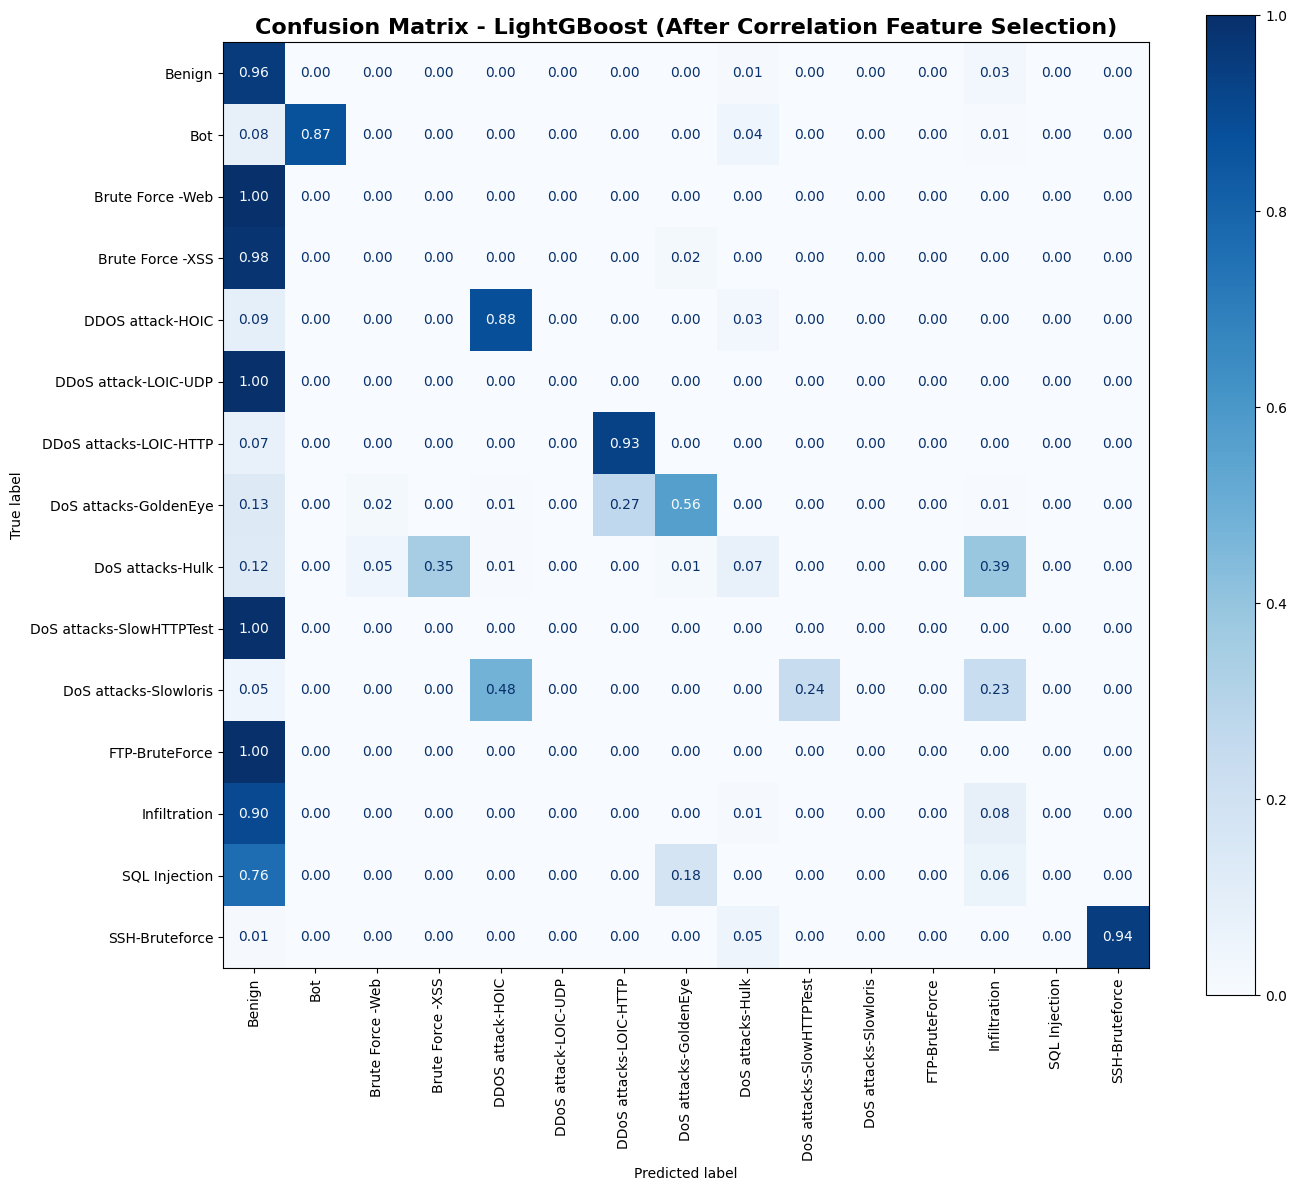

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lgb_56,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - LightGBoost (After Correlation Feature Selection)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/results/lgb56_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()